# Empirical Finance - 20999

# Lab 6: Linear Regression model

In this Lab, we develop a linear regression model aimed at predicting the payout ratio of firms within the S&P 500 universe. The model relies on a set of selected financial variables to capture relevant patterns in corporate dividend behavior. The ultimate goal is to use the estimated relationship to forecast the payout ratio for a number of out-of-sample companies.


The following primary variables were obtained from Yahoo Finance:
*   `payoutRatio`: the proportion of earnings paid to shareholders in the form of dividends. It is computed as the ratio of dividends per share to earnings per share. A higher value indicates a larger share of profits being distributed to shareholders rather than retained by the company.
*   `ebitda`: Earnings Before Interest, Taxes, Depreciation, and Amortization. It measures a company's operating performance by excluding the effects of financing and accounting decisions, providing an estimate of cash earnings generated by core operations.
*   `marketCap`: the total market value of a company’s outstanding shares of stock, calculated as share price multiplied by the number of outstanding shares. It serves as an indicator of company size and market valuation.
*   `sector`: the industry classification to which the company belongs, as defined by Yahoo Finance (e.g., Technology, Healthcare, Financial Services). It is used to group companies with similar business activities.
*   `trailingPE`: the trailing price-to-earnings ratio, computed as the current market price per share divided by the earnings per share over the previous twelve months. It indicates how much investors are willing to pay for each dollar of past earnings.

Since the variables exhibited very large numerical values, `ebitda`, `marketCap`, and `trailingPE` were log-transformed to reduce scale differences and improve interpretability.

The categorical variable sector was converted into a dummy variable, `RealEstate`, identifying firms belonging to the Real Estate sector, which appeared to be characterized by payout ratios higher than the overall average.


The selected variables are expected to capture several economic and financial factors potentially associated with a firm's payout policy:
* `ebitda` and `marketCap` reflect company size and profitability, which may influence the capacity to distribute dividends;
* `trailingPE` conveys market valuation and investor expectations, possibly related to dividend behavior;
* `RealEstate` accounts for structural differences across industries, such as the tendency of Real Estate firms to exhibit higher payout ratios.

It is important to emphasize that, in this framework, we are **NOT** attempting to study or identify the determinants of the payout ratio, **NOR** to investigate any causal relationships. Instead, our objective is to exploit statistical associations among variables solely for **predictive purposes** within a linear regression framework.

In [57]:
import pandas as pd
import numpy as np

We begin by uploading the dataset provided as an Excel spreadsheet, where the first column contains the company tickers, which will serve as the index of the resulting DataFrame.

To create this “clean” version of the dataset, refer to the bonus section below, which illustrates how the Excel file itself was generated using this script.

## Data inspection and descriptive statistics

In [58]:
df = pd.read_excel('Lab6_IS.xlsx', index_col=0)
df

,payoutRatio,ln(ebitda),ln(marketCap),RealEstate,ln(trailingPE)
MMM,0.4609,22.541505,25.218640,0,3.292168
AOS,0.3666,20.480302,22.938162,0,2.875436
ABT,0.2915,23.186864,26.120690,0,2.769758
ABBV,4.9015,24.108300,26.709622,0,5.131677
ACN,0.4872,23.226547,25.736703,0,2.993920
...,...,...,...,...,...
XEL,0.6883,22.462503,24.594662,0,3.208579
XYL,0.4021,21.340611,24.319668,0,3.653332
YUM,0.5458,21.759648,24.457505,0,3.380517
ZBRA,0.0000,20.696922,23.282582,0,3.246369


We can obtain an overview of the main descriptive statistics using the `describe()` method of the dataframe, and investigate the correlation structure with the `corr()` method.

In [59]:
df.describe()

,payoutRatio,ln(ebitda),ln(marketCap),RealEstate,ln(trailingPE)
count,437.000000,437.000000,437.000000,437.000000,437.000000
mean,0.472679,21.993773,24.570283,0.059497,3.309877
std,0.732367,1.123963,1.152302,0.236823,0.696800
min,0.000000,15.644084,22.629730,0.000000,1.517279
25%,0.109000,21.259602,23.745325,0.000000,2.948808
50%,0.314700,21.930733,24.386618,0.000000,3.246369
75%,0.591100,22.600897,25.172286,0.000000,3.575794
max,7.000000,25.837883,29.179193,1.000000,7.038930


In [60]:
df.corr()

,payoutRatio,ln(ebitda),ln(marketCap),RealEstate,ln(trailingPE)
payoutRatio,1.000000,0.069674,-0.025394,0.368644,0.297382
ln(ebitda),0.069674,1.000000,0.769916,-0.148737,-0.227488
ln(marketCap),-0.025394,0.769916,1.000000,-0.110001,0.245234
RealEstate,0.368644,-0.148737,-0.110001,1.000000,0.162954
ln(trailingPE),0.297382,-0.227488,0.245234,0.162954,1.000000


The correlation matrix suggests that the payout ratio is only weakly related to firm profitability and size, as indicated by the near-zero correlations with `ln(ebitda)` and `ln(marketCap)`.

In contrast, it shows a moderate positive association with `RealEstate`, confirming that companies in this sector tend to display higher payout ratios.

A similar, though smaller, positive correlation is observed with `ln(trailingPE)`, implying that firms with higher market valuations may also exhibit more generous dividend policies.

Overall, the payout ratio appears more closely related to sectoral characteristics and market valuation than to profitability or firm size, though these are merely **descriptive associations** rather than **causal relationships**.

## The estimation of a linear regression model
We now aim to estimate a linear regression function of the form
$$
\mathrm{E}[Y \mid [1, X_1, X_2, X_3, X_4]'] = \beta_0 \cdot 1 + \beta_1 X_1 + \beta_2 X_2 + \beta_3 X_3 + \beta_4 X_4,
$$
where
$$
\begin{array}{l}
  Y: \text{ payoutRatio},\\
  X_1: \text{ ln(ebitda)},\\
  X_2: \text{ ln(marketCap)},\\
  X_3: \text{ RealEstate},\\
  X_4: \text{ ln(trailingPE)}.
\end{array}
$$
The corresponding statistical model is
$$
\mathbf{y} = \mathbf{X} \boldsymbol{\beta} + \boldsymbol{\varepsilon},
$$
with
$$
\mathbf{X} = [\, \mathbf{1}_n,\; \mathbf{X}_1,\; \mathbf{X}_2,\; \mathbf{X}_3,\; \mathbf{X}_4 \,].
$$
Adopting a modern, machine learning-inspired terminology, we refer to $Y$ as the **target** and to $\mathbf{x} = [1, X_1, X_2, X_3, X_4]'$ as the **feature** vector.

In [61]:
df

,payoutRatio,ln(ebitda),ln(marketCap),RealEstate,ln(trailingPE)
MMM,0.4609,22.541505,25.218640,0,3.292168
AOS,0.3666,20.480302,22.938162,0,2.875436
ABT,0.2915,23.186864,26.120690,0,2.769758
ABBV,4.9015,24.108300,26.709622,0,5.131677
ACN,0.4872,23.226547,25.736703,0,2.993920
...,...,...,...,...,...
XEL,0.6883,22.462503,24.594662,0,3.208579
XYL,0.4021,21.340611,24.319668,0,3.653332
YUM,0.5458,21.759648,24.457505,0,3.380517
ZBRA,0.0000,20.696922,23.282582,0,3.246369


In [62]:
import statsmodels.api as sm

target = df['payoutRatio']
features = df[ ['ln(ebitda)', 'ln(marketCap)', 'RealEstate', 'ln(trailingPE)'] ]

In [63]:
features = sm.add_constant(features)
features

,const,ln(ebitda),ln(marketCap),RealEstate,ln(trailingPE)
MMM,1.0,22.541505,25.218640,0,3.292168
AOS,1.0,20.480302,22.938162,0,2.875436
ABT,1.0,23.186864,26.120690,0,2.769758
ABBV,1.0,24.108300,26.709622,0,5.131677
ACN,1.0,23.226547,25.736703,0,2.993920
...,...,...,...,...,...
XEL,1.0,22.462503,24.594662,0,3.208579
XYL,1.0,21.340611,24.319668,0,3.653332
YUM,1.0,21.759648,24.457505,0,3.380517
ZBRA,1.0,20.696922,23.282582,0,3.246369


In [64]:
GR = sm.OLS(target, features).fit()

In [65]:
type(GR)

statsmodels.regression.linear_model.RegressionResultsWrapper

In [66]:
print(GR.summary())

                            OLS Regression Results                            
Dep. Variable:            payoutRatio   R-squared:                       0.409
Model:                            OLS   Adj. R-squared:                  0.403
Method:                 Least Squares   F-statistic:                     74.62
Date:                Wed, 01 Jul 2026   Prob (F-statistic):           4.74e-48
Time:                        23:55:22   Log-Likelihood:                -368.69
No. Observations:                 437   AIC:                             747.4
Df Residuals:                     432   BIC:                             767.8
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -1.7120      0.606     -2.

Before moving forward it is important to emphasize that the coefficients obtained from this regression have **no causal interpretation**. The apparent *ceteris paribus* interpretation of these coefficients is in fact illusory, since the explanatory variables are mechanically and economically linked to one another. For instance, a higher EBITDA typically leads to a higher market capitalization, and both are likely to be related to the P/E ratio. Because of these intrinsic interdependencies, it is not possible to vary one variable while keeping the others fixed in practice. As a result, the estimated coefficients merely capture **statistical associations useful for prediction**, **NOT** than causal effects.

We now aim to reproduce all the numerical results obtained from the previous regression outputs (and additional ones) by implementing the procedures discussed in class.

To this end, it is convenient to convert both the target variable and the feature matrix into NumPy arrays, remembering to add a column of ones to the latter in order to include the intercept term.

In [67]:
df_np = df.to_numpy()
df_np

array([[ 0.4609    , 22.54150493, 25.21864045,  0.        ,  3.29216774],
       [ 0.3666    , 20.4803022 , 22.93816182,  0.        ,  2.87543599],
       [ 0.2915    , 23.18686375, 26.12068954,  0.        ,  2.76975809],
       ...,
       [ 0.54580003, 21.75964807, 24.45750491,  0.        ,  3.38051711],
       [ 0.        , 20.69692186, 23.28258189,  0.        ,  3.24636947],
       [ 0.2382    , 21.69423412, 23.58769668,  0.        ,  3.08923614]])

In [68]:
y = df_np[:,0]

X = df_np[:, 1:]

In [69]:
X

array([[22.54150493, 25.21864045,  0.        ,  3.29216774],
       [20.4803022 , 22.93816182,  0.        ,  2.87543599],
       [23.18686375, 26.12068954,  0.        ,  2.76975809],
       ...,
       [21.75964807, 24.45750491,  0.        ,  3.38051711],
       [20.69692186, 23.28258189,  0.        ,  3.24636947],
       [21.69423412, 23.58769668,  0.        ,  3.08923614]])

In [70]:
n = len(y)
n

437

In [71]:
X = np.hstack( [np.ones(n).reshape(-1,1), X] )
X

array([[ 1.        , 22.54150493, 25.21864045,  0.        ,  3.29216774],
       [ 1.        , 20.4803022 , 22.93816182,  0.        ,  2.87543599],
       [ 1.        , 23.18686375, 26.12068954,  0.        ,  2.76975809],
       ...,
       [ 1.        , 21.75964807, 24.45750491,  0.        ,  3.38051711],
       [ 1.        , 20.69692186, 23.28258189,  0.        ,  3.24636947],
       [ 1.        , 21.69423412, 23.58769668,  0.        ,  3.08923614]])

After verifying that $\mathbf{X}$ has full column rank (that is, $\mathrm{rk}[\mathbf{X}] = k$, where $k$ denotes the number of features including the intercept), we compute the OLS estimator of $\boldsymbol{\beta}$ as
$$
\hat{\boldsymbol{\beta}}_{\mathrm{OLS}} = \left( \mathbf{X}' \mathbf{X} \right)^{-1} \mathbf{X}' \mathbf{y}.
$$

In [72]:
k = X.shape[1]
k

5

In [73]:
np.linalg.matrix_rank(X) == k

np.True_

In [74]:
betaOLS = np.linalg.inv(X.T @ X) @ X.T @ y
betaOLS

array([-1.71202412,  0.63651635, -0.58151551,  0.92782181,  0.73057263])

In [75]:
GR.params

,0
const,-1.712024
ln(ebitda),0.636516
ln(marketCap),-0.581516
RealEstate,0.927822
ln(trailingPE),0.730573


Next, we compute the vectors of OLS fitted values and residuals as
$$
\begin{array}{l}
\hat{\mathbf{y}} = \mathbf{X} \hat{\boldsymbol{\beta}}_{\mathrm{OLS}}, \\
\hat{\boldsymbol{\varepsilon}} = \mathbf{y} - \hat{\mathbf{y}}.
\end{array}
$$

In [76]:
fit = X @ betaOLS
res = y- fit

In [77]:
# fit = GR.fittedvalues
# res = GR.resid

We can now verify the algebraic properties of these two vectors discussed in class. In particular (see proposition 6.20 of the Lecture Notes), we should check that:
$$
\begin{array}{l}
\text{1. } \mathbf{X}' \hat{\boldsymbol{\varepsilon}} = \mathbf{0}_k, \\
\text{2. } \hat{\mathbf{y}}' \hat{\boldsymbol{\varepsilon}} = 0, \\
\text{3. } \|\mathbf{y}\|^2 = \|\hat{\mathbf{y}}\|^2 + \|\hat{\boldsymbol{\varepsilon}}\|^2.
\end{array}
$$

In [78]:
X.T @ res

array([3.29745120e-11, 6.18849523e-10, 6.25318517e-10, 1.67066361e-12,
       9.19854668e-11])

In [79]:
y @ y - fit @ fit - res @ res

np.float64(8.517986316292081e-11)

Moreover, since the model includes the intercept, we should also verify that (see Proposition 6.21 of the Lecture Notes):
$$
\begin{array}{l}
\text{1. } \bar{\hat{\boldsymbol{\varepsilon}}} = 0, \\
\text{2. } \bar{\hat{\mathbf{y}}} = \bar{\mathbf{y}}, \\
\text{3. } \hat{\mathrm{V}}[\mathbf{y}] = \hat{\mathrm{V}}[\hat{\mathbf{y}}] + \hat{\mathrm{V}}[\hat{\boldsymbol{\varepsilon}}].
\end{array}
$$

In [80]:
res.mean()

np.float64(7.545553299903204e-14)

In [81]:
np.var(y) - np.var(fit) -np.var(res)

np.float64(1.2351231148954867e-13)

We can now compute the coefficient of determination, $R^2$, as
$$
R^2 = 1 - \frac{\sum_{i=1}^n \hat{\varepsilon}_i^2}{\sum_{i=1}^n \left( y_i - \bar{\mathbf{y}} \right)^2},
$$
or, since the intercept is included in the model and the estimation is performed via OLS,
$$
R^2 = \frac{\hat{\mathrm{V}}[\hat{\mathbf{y}}]}{\hat{\mathrm{V}}[\mathbf{y}]}.
$$

In [82]:
R2 = np.var(fit)/np.var(y)
R2

np.float64(0.40860683854038005)

In [83]:
GR.rsquared

np.float64(0.4086068385406111)

In [84]:
R2 = 1 - res @ res/(np.var(y)*n)
R2

np.float64(0.40860683854061086)

In [85]:
R2 = np.corrcoef(y, fit)[0, 1]**2
R2

np.float64(0.40860683854061014)

Finally, we can estimate the common error variance parameter $\sigma^2_\varepsilon$ as
$$
\hat{\sigma}^2_\varepsilon = \frac{\hat{\boldsymbol{\varepsilon}}' \hat{\boldsymbol{\varepsilon}}}{n - k}.
$$

In [86]:
sigma2_epsilon = res @ res/(n-k)
sigma2_epsilon

np.float64(0.320137563798085)

In [87]:
GR.scale

np.float64(0.32013756379808495)

## Inference

Inferential results rely on the sampling variance–covariance matrix of the OLS estimator, given by
$$
\mathrm{V}\!\left[\hat{\boldsymbol{\beta}}_{OLS}\right] = \sigma_\varepsilon^2 \left( \mathbf{X}' \mathbf{X} \right)^{-1},
$$
which can be estimated as
$$
\hat{\sigma}_\varepsilon^2 \left( \mathbf{X}' \mathbf{X} \right)^{-1}.
$$
In particular, the estimated standard errors of the individual coefficients of the OLS estimator correspond to the square roots of the elements along the main diagonal of this matrix:
$$
\mathrm{st.e}\!\left[\hat{\beta}_{OLS,i}\right] =
\sqrt{\hat{\sigma}_\varepsilon^2 \left[\left( \mathbf{X}' \mathbf{X} \right)^{-1}\right]_{i,i}}.
$$


In [88]:
V_betaOLS = sigma2_epsilon*np.linalg.inv(X.T @ X)
V_betaOLS

array([[ 3.67786366e-01, -8.46569713e-03, -6.67279183e-03,
        -7.94552033e-03, -4.96575829e-03],
       [-8.46569713e-03,  2.61330372e-03, -2.24802867e-03,
        -2.62299376e-04,  1.88514392e-03],
       [-6.67279183e-03, -2.24802867e-03,  2.53701261e-03,
         6.77780835e-04, -1.89131470e-03],
       [-7.94552033e-03, -2.62299376e-04,  6.77780835e-04,
         1.38142757e-02, -1.13620397e-03],
       [-4.96575829e-03,  1.88514392e-03, -1.89131470e-03,
        -1.13620397e-03,  3.03397009e-03]])

In [89]:
ste_betaOLS = np.sqrt( np.diag(V_betaOLS) )
ste_betaOLS

array([0.60645393, 0.05112048, 0.05036877, 0.11753415, 0.05508149])

In [90]:
GR.bse

,0
const,0.606454
ln(ebitda),0.051120
ln(marketCap),0.050369
RealEstate,0.117534
ln(trailingPE),0.055081


The $t$-ratios of the OLS coefficient estimates are given by
$$
\mathrm{t.ratio}\!\left[\hat{\beta}_{OLS,i}\right] =
\frac{\hat{\beta}_{OLS,i}}{\mathrm{st.e}\!\left[\hat{\beta}_{OLS,i}\right]}.
$$

In [91]:
tratios = betaOLS/ste_betaOLS
tratios

array([ -2.82300772,  12.45129787, -11.54516082,   7.89406167,
        13.26348799])

In [92]:
GR.tvalues

,0
const,-2.823008
ln(ebitda),12.451298
ln(marketCap),-11.545161
RealEstate,7.894062
ln(trailingPE),13.263488


Under the strong OLS assumptions, and taking into account that the common error variance is not known but estimated from the data, these $t$-ratios are assumed to follow a Student's $t$ distribution with $n - k$ degrees of freedom.

Before relying on this result, it is reasonable to verify whether the strong OLS assumptions are likely to hold. One way to do so is to check whether the residuals of the model are *approximately* normally distributed.

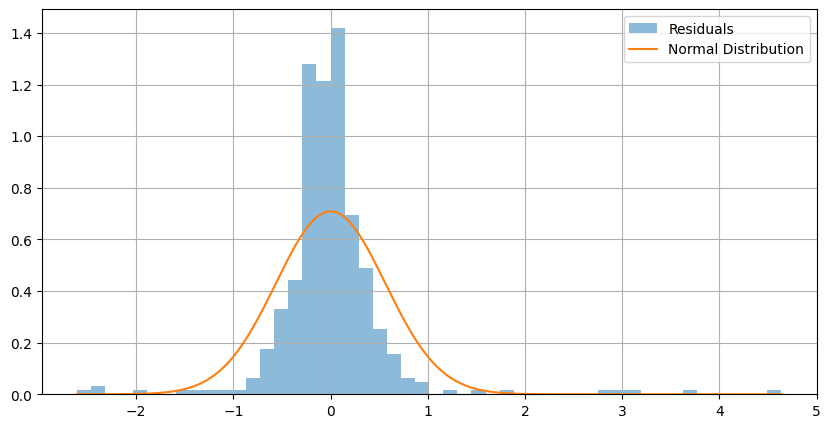

In [93]:
import matplotlib.pyplot as plt
from scipy.stats import norm

plt.figure(figsize=(10,5))

plt.hist(res, density = True, bins = 50, label = 'Residuals', alpha = 0.5  )

mu, sigma = np.mean(res), np.std(res)
x = np.linspace(min(res), max(res), 200)
plt.plot(x, norm.pdf(x, mu, sigma), label = 'Normal Distribution')
plt.legend()
plt.grid(True)
plt.show()

Although there is strong statistical evidence against the normality of the residuals (as is almost always the case in empirical applications), we can proceed nonetheless.

In practice, the lack of perfect normality is of limited concern when the residuals exhibit a unimodal and fairly symmetric distribution, and when the sample size $n$ is large. This is precisely our situation.

First, we can compute the $p$-values for testing the statistical significance of each estimated coefficient as
$$
p = 2 F_{t(n - k)} \!\left( - \left| \mathrm{t.ratio}\!\left[\hat{\beta}_{OLS,i}\right] \right| \right),
$$
where $F_{t(\nu)}(\cdot)$ denotes the cumulative distribution function of a Student's $t$ distribution with $\nu$ degrees of freedom.

In [94]:
from scipy.stats import t

pvals = 2*t(n-k).cdf( -np.abs( tratios) )
pvals

array([4.97738865e-03, 1.26886166e-30, 4.65868215e-27, 2.43449600e-14,
       6.37428170e-34])

In [95]:
GR.pvalues

,0
const,4.977389e-03
ln(ebitda),1.268862e-30
ln(marketCap),4.658682e-27
RealEstate,2.434496e-14
ln(trailingPE),6.374282e-34


Next, we can compute the lower and upper bounds of the $(1 - \alpha)$ confidence interval for each coefficient as
$$
\Pr \!\left[
\hat{\beta}_{\mathrm{OLS},i} + t_{n - k;\,\frac{\alpha}{2}} \, \sigma_\varepsilon
\sqrt{\left[\left(\mathbf{X}' \mathbf{X}\right)^{-1}\right]_{i,i}}
\leq \beta_i \leq
\hat{\beta}_{\mathrm{OLS},i} + t_{n - k;\,1 - \frac{\alpha}{2}} \, \sigma_\varepsilon
\sqrt{\left[\left(\mathbf{X}' \mathbf{X}\right)^{-1}\right]_{i,i}}
\right] = 1 - \alpha,
$$
where $t_{\nu; \alpha}$ is the $\alpha$-quantile of a Student-$t$ distribution with $\nu$ degrees of freedom.

Using vector notation and the previously computed vector of standard errors, we can also write these intervals as
$$
\Pr \!\left[
\hat{\boldsymbol{\beta}}_{\mathrm{OLS}} + t_{n - k;\,\frac{\alpha}{2}} \, \mathrm{st.e.}\!\left[\hat{\boldsymbol{\beta}}_{\mathrm{OLS}}\right]
\leq \boldsymbol{\beta} \leq
\hat{\boldsymbol{\beta}}_{\mathrm{OLS}} + t_{n - k;\,1 - \frac{\alpha}{2}} \, \mathrm{st.e.}\!\left[\hat{\boldsymbol{\beta}}_{\mathrm{OLS}}\right]
\right] = 1 - \alpha.
$$

In [96]:
alpha = 0.05

lowerBound_BetaOLS = betaOLS +t(n-k).ppf(alpha/2)*ste_betaOLS
lowerBound_BetaOLS

array([-2.90399143,  0.53604055, -0.68051383,  0.69681191,  0.62231159])

In [97]:
GR.conf_int(alpha)

,0,1
const,-2.903991,-0.520057
ln(ebitda),0.536041,0.736992
ln(marketCap),-0.680514,-0.482517
RealEstate,0.696812,1.158832
ln(trailingPE),0.622312,0.838834


## Partial regressions and semi-partial $R^2$
We now aim to verify that the result of the Partial Regression Theorem holds.  
With reference to the global regression (GR) analyzed so far,

 $
\text{(GR)}$: $\quad \text{payoutRatio} = \beta_0 + \beta_1 \,\text{ln(ebitda)} + \beta_2 \,\text{ln(marketCap)} + \beta_3 \,\text{RealEstate} + \beta_4 \,\text{ln(trailingPE)} + \varepsilon,
$

we focus on the last regressor, $\text{ln(trailingPE)}$, and its coefficient $\beta_4$.

To obtain its OLS estimate, $\hat{\beta}_{\mathrm{OLS},4}$, in the equivalent way suggested by the Partial Regression Theorem, we first run a regression of $\text{ln(trailingPE)}$ on an intercept and on the other explanatory variables:

 $
\text{(PR1)}$: $\quad \text{ln(trailingPE)} = \alpha_0 + \alpha_1 \,\text{ln(ebitda)} + \alpha_2 \,\text{ln(marketCap)} + \alpha_3 \,\text{RealEstate} + u.
$

Next, we estimate a second auxiliary regression of the original target variable, $\text{payoutRatio}$, on a constant and on the residuals from (PR1), denoted by $\hat{u}$:

$
\text{(PR2)}$: $\quad \text{payoutRatio} = \gamma_0 + \gamma_1 \hat{u} + \eta.
$

Finally, we should verify that
$$
\hat{\gamma}_{\mathrm{OLS},1} = \hat{\beta}_{\mathrm{OLS},4}.
$$

In [98]:
betaOLS[-1]

np.float64(0.7305726273006308)

In [99]:
lnPE = X[:, -1]
X_minuslnPE = X[:, :-1]

In [100]:
PR1 = sm.OLS(lnPE, X_minuslnPE).fit()

In [101]:
res_PR1 = PR1.resid
res_PR1 = sm.add_constant(res_PR1)

In [102]:
PR2 = sm.OLS(y, res_PR1).fit()

In [103]:
PR2.params

array([0.47267941, 0.73057263])

The $R^2$ of regression $\text{(PR2)}$ represents the **semi-partial $R^2$** associated with the regressor $\text{ln(trailingPE)}$.

This metric measures the marginal contribution to the $R^2$ of the global regression that is brought by the component of $\text{ln(trailingPE)}$ uncorrelated with the other features.

In [104]:
PR2.rsquared

np.float64(0.2408285930829247)

Indeed, this semi-partial $R^2$ can also be obtained as the difference between the $R^2$ of regression $\text{(GR)}$ and the $R^2$ of the regression of the main target variable, $\text{payoutRatio}$, on a constant and on all features EXCEPT $\text{ln(trailingPE)}$, namely

$\text{(GR-4)}$: $\quad \text{payoutRatio} = \beta_0 + \beta_1 \,\text{ln(ebitda)} + \beta_2 \,\text{ln(marketCap)} + \beta_3 \,\text{RealEstate} + \xi$.

In [105]:
GR_minusPE = sm.OLS(y, X_minuslnPE).fit()

In [106]:
GR_minusPE.rsquared

np.float64(0.16777824545768627)

In [107]:
GR.rsquared - GR_minusPE.rsquared

np.float64(0.2408285930829248)

Alternatively, as stated in Proposition~6.40 of the Lecture Notes, the semi-partial $R^2$ for a given feature, as well as for all features collectively, can be computed from the previously obtained $t$-ratios as
$$
R^2_{SP,i} = \frac{\mathrm{t.ratio}\!\left[\hat{\beta}_{OLS,i}\right]^2 (1 - R^2)}{n - k},
$$
where the $R^2$ in the formula refers to that of regression (GR).

In [108]:
semipartialR2 = tratios**2*(1-R2)/(n-k)
semipartialR2

array([0.0109098 , 0.21223734, 0.18247044, 0.08530875, 0.24082859])

## Forecasts
We can now turn to the main purpose of this model, as of any predictive model: **generating forecasts**.

A subset of firms was randomly retained from the original sample used to estimate the model, and these observations now serve as our test sample, or out-of-sample framework. In particular, we use their features, collected in the matrix $\mathbf{X}_f$ according to standard notation, to produce forecasts of the corresponding target variable, along with the confidence intervals for the expected values and the prediction intervals for the individual forecasts.

Finally, since the true (realized) values of the target are available, we verify whether these realizations fall within the estimated intervals and evaluate the resulting forecast errors.

In [109]:
OOS_df = pd.read_excel('Lab6_OOS.xlsx', index_col=0)

In [110]:
OOS_df

,payoutRatio,ln(ebitda),ln(marketCap),RealEstate,ln(trailingPE)
AMT,1.0718,22.629588,25.183512,1,3.385040
CI,0.2625,23.178572,24.994217,0,2.473480
EOG,0.3808,23.187970,24.806342,0,2.384902
HPQ,0.4159,22.249974,23.863755,0,2.196416
MCK,0.0922,22.596144,25.383942,0,3.286111
PNW,0.7381,21.430839,23.086468,0,2.907070
TDY,0.0000,21.094553,23.908607,0,3.396180
ZTS,0.3253,22.107308,24.692351,0,3.005100


In [111]:
OOS_features = OOS_df[['ln(ebitda)', 'ln(marketCap)', 'RealEstate', 'ln(trailingPE)']]
OOS_target = OOS_df['payoutRatio']

OOS_features = sm.add_constant(OOS_features)

In [112]:
OOS_features

,const,ln(ebitda),ln(marketCap),RealEstate,ln(trailingPE)
AMT,1.0,22.629588,25.183512,1,3.385040
CI,1.0,23.178572,24.994217,0,2.473480
EOG,1.0,23.187970,24.806342,0,2.384902
HPQ,1.0,22.249974,23.863755,0,2.196416
MCK,1.0,22.596144,25.383942,0,3.286111
PNW,1.0,21.430839,23.086468,0,2.907070
TDY,1.0,21.094553,23.908607,0,3.396180
ZTS,1.0,22.107308,24.692351,0,3.005100


In [113]:
pred = GR.get_prediction(OOS_features)
type(pred)

statsmodels.regression._prediction.PredictionResults

In [114]:
forecasts = pred.summary_frame(alpha)
forecasts

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
AMT,1.448315,0.116361,1.219611,1.677019,0.312965,2.583666
CI,0.314048,0.047590,0.220512,0.407583,-0.801956,1.430051
EOG,0.364569,0.050324,0.265659,0.463479,-0.751898,1.481036
HPQ,0.177946,0.051555,0.076616,0.279276,-0.938738,1.294630
MCK,0.310378,0.034301,0.242961,0.377796,-0.803740,1.424497
PNW,0.627743,0.050733,0.528028,0.727457,-0.488796,1.744281
TDY,0.292935,0.036238,0.221710,0.364159,-0.821421,1.407290
ZTS,0.196098,0.032175,0.132858,0.259337,-0.917776,1.309971


On a completely unconditional basis, the approximate 95% probability interval for the target variable $Y$ can be computed from its sample mean and standard deviation, estimated using the in-sample observations $\mathbf{y}$, as
$$
\bar{\mathbf{y}} \pm 2 \, \hat{\mathrm{st.d}}[\mathbf{y}].
$$
Any interval narrower than this benchmark indicates that the regression analysis provides informative predictive power.


In [115]:
stats = df.describe()
stats

,payoutRatio,ln(ebitda),ln(marketCap),RealEstate,ln(trailingPE)
count,437.000000,437.000000,437.000000,437.000000,437.000000
mean,0.472679,21.993773,24.570283,0.059497,3.309877
std,0.732367,1.123963,1.152302,0.236823,0.696800
min,0.000000,15.644084,22.629730,0.000000,1.517279
25%,0.109000,21.259602,23.745325,0.000000,2.948808
50%,0.314700,21.930733,24.386618,0.000000,3.246369
75%,0.591100,22.600897,25.172286,0.000000,3.575794
max,7.000000,25.837883,29.179193,1.000000,7.038930


In [116]:
forecasts['pi_lower'] = stats.loc['mean']['payoutRatio']-2*stats.loc['std']['payoutRatio']

In [117]:
forecasts['pi_upper'] = stats.loc['mean']['payoutRatio']+2*stats.loc['std']['payoutRatio']

In [118]:
forecasts

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper,pi_lower,pi_upper
AMT,1.448315,0.116361,1.219611,1.677019,0.312965,2.583666,-0.992055,1.937414
CI,0.314048,0.047590,0.220512,0.407583,-0.801956,1.430051,-0.992055,1.937414
EOG,0.364569,0.050324,0.265659,0.463479,-0.751898,1.481036,-0.992055,1.937414
HPQ,0.177946,0.051555,0.076616,0.279276,-0.938738,1.294630,-0.992055,1.937414
MCK,0.310378,0.034301,0.242961,0.377796,-0.803740,1.424497,-0.992055,1.937414
PNW,0.627743,0.050733,0.528028,0.727457,-0.488796,1.744281,-0.992055,1.937414
TDY,0.292935,0.036238,0.221710,0.364159,-0.821421,1.407290,-0.992055,1.937414
ZTS,0.196098,0.032175,0.132858,0.259337,-0.917776,1.309971,-0.992055,1.937414


The estimates of the expected target and its actual point forecasts are both computed as
$$
\mathbf{X}_f \hat{\boldsymbol{\beta}}_{\mathrm{OLS}}.
$$

In [119]:
X_f = OOS_features.to_numpy()
X_f

array([[ 1.        , 22.62958835, 25.18351215,  1.        ,  3.38503978],
       [ 1.        , 23.17857201, 24.99421738,  0.        ,  2.47347961],
       [ 1.        , 23.18796978, 24.80634237,  0.        ,  2.38490158],
       [ 1.        , 22.24997406, 23.86375521,  0.        ,  2.19641614],
       [ 1.        , 22.59614433, 25.38394187,  0.        ,  3.28611136],
       [ 1.        , 21.43083946, 23.08646769,  0.        ,  2.90707006],
       [ 1.        , 21.09455349, 23.90860689,  0.        ,  3.39617995],
       [ 1.        , 22.10730768, 24.69235078,  0.        ,  3.00510006]])

In [120]:
pred_target = X_f @ betaOLS
pred_target

array([1.44831532, 0.31404752, 0.3645689 , 0.17794604, 0.31037845,
       0.62774252, 0.2929346 , 0.19609771])

In [121]:
forecasts['mean']

,mean
AMT,1.448315
CI,0.314048
EOG,0.364569
HPQ,0.177946
MCK,0.310378
PNW,0.627743
TDY,0.292935
ZTS,0.196098


Under strong OLS assumptions extended to the forecasting context (with unknown error variance term), the confidence interval for the expected value of an individual target, characterized by a single row of features $\mathbf{x}_f$, is given by
$$ \text{Pr} \left[ \text{E} \left[ y_f \mid \mathbf{X}, \mathbf{x}_f \right] \in \left[ \mathbf{x}_f \hat{\boldsymbol{\beta}}_{OLS} \pm t_{n-k;1-\frac{\alpha}{2}} \, \hat{\sigma}_\varepsilon \, \sqrt{\mathbf{x}_f \left( \mathbf{X}'\mathbf{X} \right)^{-1} \mathbf{x}_f'} \right] \right] = 1 - \alpha. $$

In [122]:
X_f[0, :]

array([ 1.        , 22.62958835, 25.18351215,  1.        ,  3.38503978])

In [123]:
pred_target[0] +t(n-k).ppf(alpha/2)*np.sqrt( sigma2_epsilon* X_f[0, :] @ np.linalg.inv(X.T @ X) @ X_f[0, :].T )

np.float64(1.2196112157437948)

In [124]:
forecasts.iloc[0]['mean_ci_lower']

np.float64(1.219611215743485)

In [125]:
pred_target[0] +t(n-k).ppf(1-alpha/2)*np.sqrt( sigma2_epsilon*(X_f[0,:] @ np.linalg.inv(X.T @ X) @ X_f[0,:].T) )

np.float64(1.677019424902264)

In [126]:
forecasts.iloc[0]['mean_ci_upper']

np.float64(1.67701942490196)

Alternatively, all intervals can be obtained in a vectorized form by extracting the main diagonal of the matrix $\mathbf{X}_f \left(\mathbf{X}' \mathbf{X}\right)^{-1} \mathbf{X}_f'$, which contains the terms $\mathbf{x}_f \left(\mathbf{X}' \mathbf{X}\right)^{-1} \mathbf{x}_f'$ for each new observation.

In [127]:
np.sqrt( sigma2_epsilon*np.diag(X_f @ np.linalg.inv(X.T @ X) @ X_f.T) )

array([0.116361  , 0.04758953, 0.05032396, 0.05155503, 0.03430084,
       0.05073331, 0.03623792, 0.03217513])

In [128]:
forecasts['mean_se']

,mean_se
AMT,0.116361
CI,0.047590
EOG,0.050324
HPQ,0.051555
MCK,0.034301
PNW,0.050733
TDY,0.036238
ZTS,0.032175


In [129]:
lowerBound_expectedTarget = pred_target +t(n-k).ppf(alpha/2)*np.sqrt( sigma2_epsilon*np.diag(X_f @ np.linalg.inv(X.T @ X) @ X_f.T) )
lowerBound_expectedTarget

array([1.21961122, 0.2205117 , 0.26565865, 0.07661615, 0.24296116,
       0.5280277 , 0.22171004, 0.13285845])

In [130]:
upperBound_expectedTarget = pred_target +t(n-k).ppf(1-alpha/2)*np.sqrt( sigma2_epsilon*np.diag(X_f @ np.linalg.inv(X.T @ X) @ X_f.T) )
upperBound_expectedTarget

array([1.67701942, 0.40758333, 0.46347916, 0.27927592, 0.37779574,
       0.72745734, 0.36415917, 0.25933698])

In [131]:
forecasts[['mean_ci_lower', 'mean_ci_upper']]

,mean_ci_lower,mean_ci_upper
AMT,1.219611,1.677019
CI,0.220512,0.407583
EOG,0.265659,0.463479
HPQ,0.076616,0.279276
MCK,0.242961,0.377796
PNW,0.528028,0.727457
TDY,0.221710,0.364159
ZTS,0.132858,0.259337


The $(1-\alpha$)-forecast interval of the target value of each new indivdual can be computed as
$$ \Pr \left[ y_f \in \left[ \mathbf{x}_f \hat{\boldsymbol{\beta}}_{OLS} \pm z_{1-\frac{\alpha}{2}} \, \sigma_\varepsilon \, \sqrt{1+\mathbf{x}_f \left( \mathbf{X}'\mathbf{X} \right)^{-1} \mathbf{x}_f'} \right] \right] = 1 - \alpha. $$

In [132]:
pred_target[0] +t(n-k).ppf(alpha/2)*np.sqrt( sigma2_epsilon* (1+ X_f[0, :] @ np.linalg.inv(X.T @ X) @ X_f[0, :].T) )

np.float64(0.31296481523109754)

In [133]:
forecasts.iloc[0]['obs_ci_lower']

np.float64(0.31296481523079134)

In [134]:
pred_target[0] +t(n-k).ppf(1-alpha/2)*np.sqrt( sigma2_epsilon*(1 + X_f[0,:] @ np.linalg.inv(X.T @ X) @ X_f[0,:].T) )

np.float64(2.5836658254149594)

In [135]:
forecasts.iloc[0]['obs_ci_upper']

np.float64(2.583665825414654)

Alternatively, we can rely on the more compact vectorized notation introduced earlier.

In [136]:
lowerBound_Target = pred_target +t(n-k).ppf(alpha/2)*np.sqrt( sigma2_epsilon*( 1 +np.diag(X_f @ np.linalg.inv(X.T @ X) @ X_f.T) ))
lowerBound_Target

array([ 0.31296482, -0.80195614, -0.75189804, -0.93873787, -0.80374016,
       -0.48879599, -0.82142088, -0.91777589])

In [137]:
upperBound_Target = pred_target +t(n-k).ppf(1-alpha/2)*np.sqrt( sigma2_epsilon*( 1 +np.diag(X_f @ np.linalg.inv(X.T @ X) @ X_f.T) ))
upperBound_Target

array([2.58366583, 1.43005117, 1.48103585, 1.29462994, 1.42449707,
       1.74428103, 1.40729009, 1.30997132])

Finally, since these were in fact "pseudo" out-of-sample observations for which the values of the target variable are already known, we can verify how many of them fall within the previously computed confidence intervals for the expected targets and within the prediction intervals for the realized targets themselves.

In [138]:
realizedTarget = OOS_target.to_numpy()
realizedTarget

array([1.0718    , 0.2625    , 0.3808    , 0.4159    , 0.0922    ,
       0.7381    , 0.        , 0.32529998])

In [139]:
(lowerBound_expectedTarget <= realizedTarget) & (realizedTarget <= upperBound_expectedTarget)

array([False,  True,  True, False, False, False, False, False])

In [140]:
(lowerBound_Target <= realizedTarget) & (realizedTarget <= upperBound_Target)

array([ True,  True,  True,  True,  True,  True,  True,  True])

Alternatively, we can compute the actual forecast errors, defined as $\mathbf{y}_f - \mathbf{X}_f \hat{\boldsymbol{\beta}}_{OLS}$, and analyze them by calculating, for instance, their mean and the residual mean squared error.

In [141]:
forecast_errors = realizedTarget - pred_target
forecast_errors

array([-0.37651532, -0.05154752,  0.0162311 ,  0.23795396, -0.21817845,
        0.11035748, -0.2929346 ,  0.12920227])

In [142]:
(forecast_errors**2).mean()

np.float64(0.04544887350887111)

In [143]:
forecast_errors_mean = realizedTarget - stats.loc['mean']['payoutRatio']
forecast_errors_mean

array([ 0.59912059, -0.21017941, -0.09187941, -0.05677941, -0.38047941,
        0.26542059, -0.47267941, -0.14737943])

In [144]:
(forecast_errors_mean**2).mean()

np.float64(0.10939322264388499)